In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
deliveries = pd.read_csv('dataset/deliveries.csv')
matches = pd.read_csv('dataset/matches.csv')

In [96]:
pp_deliveries = deliveries[
    (deliveries['over'] < 6) & 
    (deliveries['inning'].isin([1, 2]))
].copy()

In [97]:
pp_stats = pp_deliveries.groupby(['match_id', 'inning']).agg(
    pp_runs=('total_runs', 'sum'),
    pp_wickets=('is_wicket', 'sum')
).reset_index()

In [98]:
pp_pivot = pp_stats.pivot(index='match_id', columns='inning', values=['pp_runs', 'pp_wickets'])

In [99]:
pp_pivot.columns = [f'Inning{col[1]}_{col[0]}' for col in pp_pivot.columns]
pp_data = pp_pivot.reset_index().fillna(0)

In [100]:
pp_data


,match_id,Inning1_pp_runs,Inning2_pp_runs,Inning1_pp_wickets,Inning2_pp_wickets
0,335982,61.0,26.0,1.0,4.0
1,335983,53.0,63.0,1.0,1.0
2,335984,40.0,55.0,2.0,1.0
3,335985,47.0,40.0,3.0,1.0
4,335986,39.0,26.0,2.0,3.0
...,...,...,...,...,...
1090,1426307,61.0,84.0,0.0,2.0
1091,1426309,45.0,63.0,4.0,1.0
1092,1426310,50.0,47.0,1.0,1.0
1093,1426311,68.0,51.0,3.0,1.0


In [101]:
final_df = pd.merge(pp_data, matches[['id', 'team1', 'team2', 'winner']], left_on='match_id', right_on='id')

In [102]:
final_df.head()

,match_id,Inning1_pp_runs,Inning2_pp_runs,Inning1_pp_wickets,Inning2_pp_wickets,id,team1,team2,winner
0,335982,61.0,26.0,1.0,4.0,335982,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
1,335983,53.0,63.0,1.0,1.0,335983,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings
2,335984,40.0,55.0,2.0,1.0,335984,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils
3,335985,47.0,40.0,3.0,1.0,335985,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore
4,335986,39.0,26.0,2.0,3.0,335986,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders


C:\Users\aram3211\AppData\Local\Temp\ipykernel_1504\1841119162.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='winner_label_temp', y='Inning1_pp_runs', data=final_df, palette='Pastel1', inner="quart")


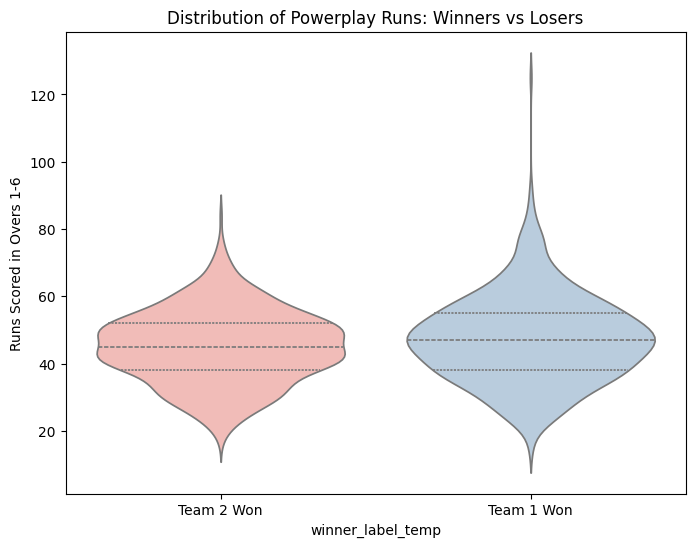

In [104]:
def encode_winner(row):
    return 1 if row['winner'] == row['team1'] else 0

# Create the visualization with winner_label before it's officially created
plt.figure(figsize=(8, 6))
final_df['winner_label_temp'] = final_df.apply(encode_winner, axis=1)
sns.violinplot(x='winner_label_temp', y='Inning1_pp_runs', data=final_df, palette='Pastel1', inner="quart")
plt.xticks([0, 1], ['Team 2 Won', 'Team 1 Won'])
plt.title('Distribution of Powerplay Runs: Winners vs Losers')
plt.ylabel('Runs Scored in Overs 1-6')
plt.show()

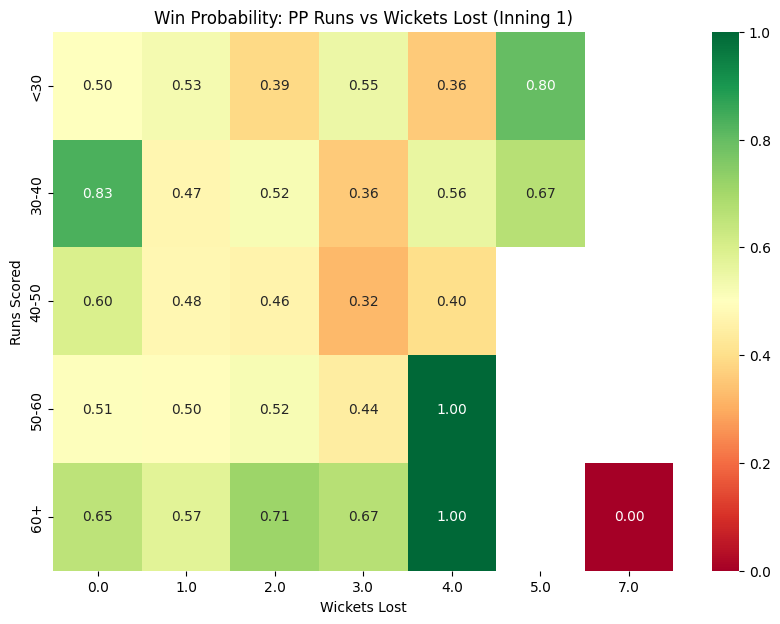

In [105]:
final_df['winner_label'] = final_df.apply(encode_winner, axis=1)

# Now create the heatmap
final_df['run_bins'] = pd.cut(final_df['Inning1_pp_runs'], 
                             bins=[0, 30, 40, 50, 60, 100], 
                             labels=['<30', '30-40', '40-50', '50-60', '60+'])

heatmap_data = final_df.groupby(['run_bins', 'Inning1_pp_wickets'])['winner_label'].mean().unstack()

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Win Probability: PP Runs vs Wickets Lost (Inning 1)')
plt.xlabel('Wickets Lost')
plt.ylabel('Runs Scored')
plt.show()

In [106]:
final_df['run_diff'] = final_df['Inning1_pp_runs'] - final_df['Inning2_pp_runs']
final_df['wk_diff'] = final_df['Inning1_pp_wickets'] - final_df['Inning2_pp_wickets']

features = ['Inning1_pp_runs', 'Inning2_pp_runs', 'Inning1_pp_wickets', 'Inning2_pp_wickets', 'run_diff', 'wk_diff']
X = final_df[features]
y = final_df['winner_label']

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=67)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",67
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [108]:
print(f"Model Training Accuracy: {accuracy_score(y_test, model.predict(X_test)):.2%}")

Model Training Accuracy: 57.53%


1. Middle Order Erasure Effect
2. Venue Bias

In [109]:
def predict_winner(i1_runs, i1_wickets, i2_runs, i2_wickets):
    input_data = pd.DataFrame([[i1_runs, i2_runs, i1_wickets, i2_wickets, i1_runs - i2_runs, i1_wickets - i2_wickets]], columns=features)
    prediction = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0]
    
    winner = "Team 1 (Batting First)" if prediction == 1 else "Team 2 (Batting Second)"
    print(f"Predicted Winner: {winner}")
    print(f"Confidence: {max(prob):.2%}")

In [113]:
predict_winner(70, 1, 40, 3)

Predicted Winner: Team 1 (Batting First)
Confidence: 85.07%


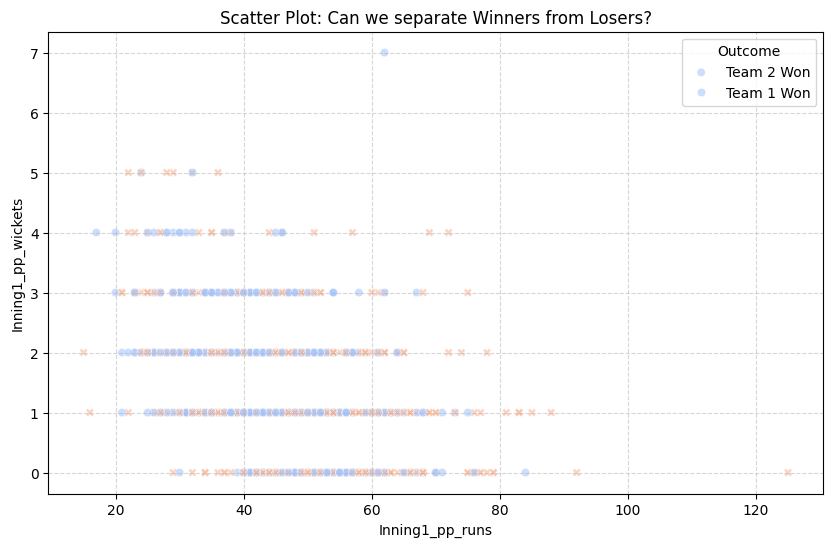

In [114]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, 
                x='Inning1_pp_runs', 
                y='Inning1_pp_wickets', 
                hue='winner_label', 
                style='winner_label',
                alpha=0.6, 
                palette='coolwarm')

plt.title('Scatter Plot: Can we separate Winners from Losers?')
plt.legend(title='Outcome', labels=['Team 2 Won', 'Team 1 Won'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

C:\Users\aram3211\AppData\Local\Temp\ipykernel_1504\44254710.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='Spectral')


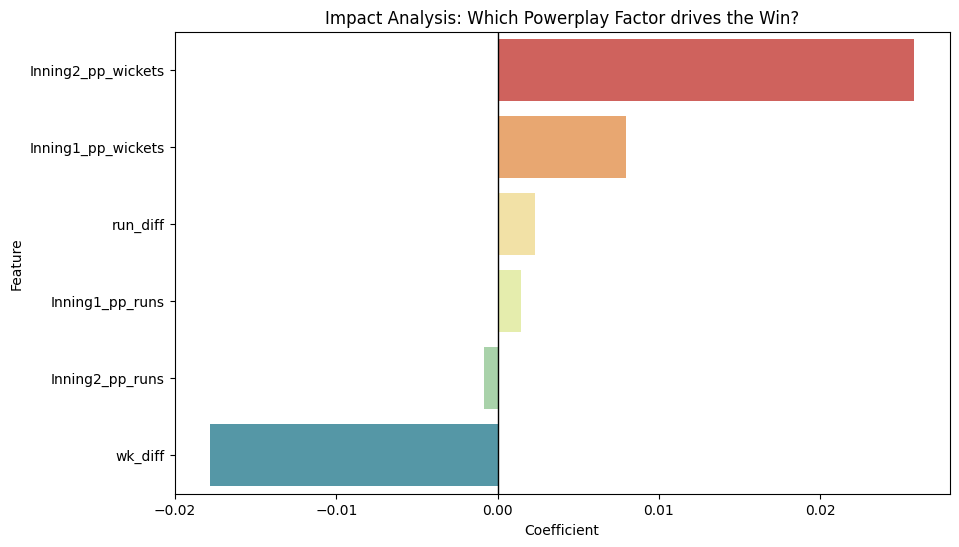

Predicted Win Probability for Team 1: 66.40%


C:\Users\aram3211\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [94]:
import numpy as np
from sklearn.linear_model import LinearRegression

features = ['Inning1_pp_runs', 'Inning2_pp_runs', 'Inning1_pp_wickets', 'Inning2_pp_wickets', 'run_diff', 'wk_diff']
X = final_df[features]
y = final_df['winner_label'] # 1 for Team 1 win, 0 for Team 2

# 2. Train Multilinear Regression
reg_model = LinearRegression()
reg_model.fit(X, y)

# 3. Analytics: Coefficients (The "Impact" of each stat)
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': reg_model.coef_})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# 4. Colorful Visual: Feature Impact Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='Spectral')
plt.title('Impact Analysis: Which Powerplay Factor drives the Win?')
plt.axvline(0, color='black', lw=1)
plt.show()

# 5. Prediction Function (Outputs a Probability %)
def predict_win_percentage(i1r, i1w, i2r, i2w):
    rd = i1r - i2r
    wd = i1w - i2w
    input_data = np.array([[i1r, i2r, i1w, i2w, rd, wd]])
    prob = reg_model.predict(input_data)[0]
    
    # Clip probability between 0 and 1
    prob = max(0, min(1, prob))
    print(f"Predicted Win Probability for Team 1: {prob:.2%}")

# Example: 60/0 vs 40/3
predict_win_percentage(60, 0, 40, 3)

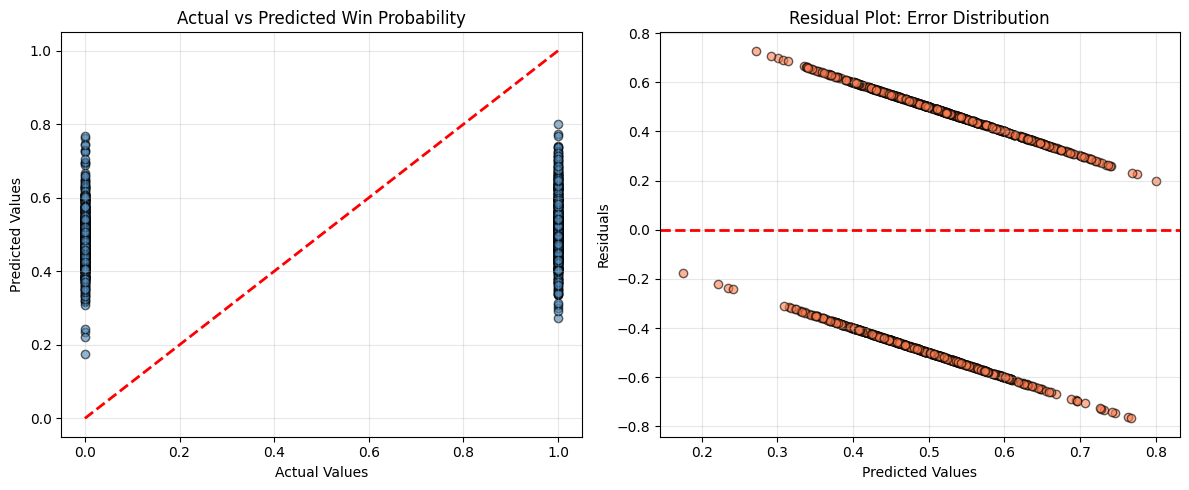

Model Performance Metrics:
R² Score: 0.0324
RMSE: 0.4918
MAE: 0.4837


In [112]:
# Make predictions on the entire dataset
y_pred = reg_model.predict(X)

# Graph 1: Actual vs Predicted Values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Win Probability')
plt.grid(True, alpha=0.3)

# Graph 2: Residuals Plot
residuals = y - y_pred

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot: Error Distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model Performance Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print(f"Model Performance Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")